# Differentiable Likelihood

_Author: Hidde T. Jense_

In this notebook, we look at some differentiable properties of the JAX likelihood.

I will show how to:
- Compute gradients and Hessians,
- Use a differentiable optimizer to find the best-fitting foreground (for constant cosmology).

For the gradient optimizer part at the end of this notebook, you should install [optax](https://optax.readthedocs.io/en/latest/).

In [1]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

/home/ojima/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import matplotlib.patches as mpt
import matplotlib.transforms as mtr

def add_ellipse(ax, m, s, cov, nstd=1., **kwargs):
    R = cov / (s[0] * s[1])
    erx = np.sqrt(1. + R)
    ery = np.sqrt(1. - R)

    ell = mpt.Ellipse((0, 0), width=2*erx, height=2*ery, **kwargs)
    mx, my = m
    sx, sy = s

    tf = mtr.Affine2D().rotate_deg(45).scale(nstd*sx, nstd*sy).translate(mx, my)
    ell.set_transform(tf + ax.transData)
    ax.add_patch(ell)

In [3]:
like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

cosmo_params = {
    "ombh2": 0.0225,
    "omch2": 0.1193,
    "cosmomc_theta": 104.073e-4,
    "ns": 0.9709,
    "logA": 3.056,
    "tau": 0.0603
}

cosmo_params["As"] = 1e-10 * np.exp(cosmo_params.pop("logA"))

pars = camb.set_params(lens_potential_accuracy=8, lmax=8500, **cosmo_params)
res = camb.get_results(pars)
spec = res.get_cmb_power_spectra(CMB_unit="muK")["total"]

Assuming data rows are in the correct order as it was before version 1.0.


In [4]:
# Some of our parameters have external priors, for example map-level calibration priors.
# We define these here:
priors = {
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    # This prior doesn't appear in MFLike, but as pa4_f220 doesn't contain any polarization data,
    # I add it here to keep it well-behaved when taking derivatives of the log-posterior!
    "calE_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.01),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),
}

# All of these priors are simple Gaussians.

In [5]:
# JAX can compute derivatives for you using automatic differentiation.
# Let's define a simple log-posterior function:

parameters = like.parameters + fg_model.parameters

@jax.jit
def logpost(theta):
    # First, we need a prior contribution.
    # We use the list of named parameters defined above to find the index of each parameter in the vector.
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    # We need to split the parameter vectors into the likelihood and foreground parts.
    theta_like = theta[:len(like.parameters)]
    theta_fg = theta[len(like.parameters):]

    # Then we need a likelihood contribution.
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike = -0.5 * like.chisquare(spec[:,0], spec[:,3], spec[:,1], foregrounds, theta_like)

    return logprior + loglike

In [6]:
# Similar to the previous notebook's example, we can evaluate this function:
parameter_values = {
    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.09,
    "a_s": 2.9,
    "beta_s": -2.8,
    "a_pste": -0.025,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 0.98,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 0.985,
    "calE_dr6_pa5_f150": 0.995,
    "calE_dr6_pa6_f090": 1.00,
    "calE_dr6_pa6_f150": 0.995,

    "bandint_shift_dr6_pa4_f220": 5.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": -1.0,
    "bandint_shift_dr6_pa6_f090": 1.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

theta = jnp.array([ parameter_values[p] for p in parameters ])

logp = logpost(theta)
print(f"log(post) = {logp:.2f}")
# Note that our log prior function is not properly normalized, so this value by itself is not super meaningful.

log(post) = -811.63


In [7]:
# We need a log-posterior function that only takes in X parameters and keeps the remainder fixed.
def model_logpost(param_names):
    fit_idx = jnp.array([ parameters.index(p) for p in param_names ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    def restricted_logpost(theta_x):
        theta = theta_default.at[fit_idx].set(theta_x)
        return logpost(theta)

    return jax.jit(restricted_logpost)

In [8]:
parameters_baseline = [
    "a_tSZ", "a_kSZ", "alpha_tSZ", "xi", "a_c", "a_p", "beta_cib", "a_s", "beta_s",
    "a_gtt", "a_gte", "a_gee", "a_pste", "a_psee",
    "calG_all", "cal_dr6_pa4_f220", "cal_dr6_pa5_f090", "cal_dr6_pa5_f150", "cal_dr6_pa6_f090", "cal_dr6_pa6_f150",
    "calE_dr6_pa5_f090", "calE_dr6_pa5_f150", "calE_dr6_pa6_f090", "calE_dr6_pa6_f150",
    "bandint_shift_dr6_pa4_f220", "bandint_shift_dr6_pa5_f090", "bandint_shift_dr6_pa5_f150", "bandint_shift_dr6_pa6_f090", "bandint_shift_dr6_pa6_f150",
]

logpost_baseline = model_logpost(parameters_baseline)
theta_baseline = jnp.array([ parameter_values[p] for p in parameters_baseline ])

# Now, we can ask JAX to compute a gradient for us:
logpost_grad = jax.grad(logpost_baseline)

# It really is as simple as that!
# Now, let's see in which direction our log-posterior changes:
grad_theta = logpost_grad(theta_baseline)

for i, p in enumerate(parameters_baseline):
    print(f"d log(post) / d {p:<30s} = {grad_theta[i]:+.3e}")

d log(post) / d a_tSZ                          = -1.089e+01
d log(post) / d a_kSZ                          = +9.932e+00
d log(post) / d alpha_tSZ                      = -4.146e+01
d log(post) / d xi                             = -2.165e+02
d log(post) / d a_c                            = +3.375e+01
d log(post) / d a_p                            = +6.960e+01
d log(post) / d beta_cib                       = +2.891e+02
d log(post) / d a_s                            = -2.101e+02
d log(post) / d beta_s                         = +7.278e+02
d log(post) / d a_gtt                          = +6.764e+00
d log(post) / d a_gte                          = +5.393e+00
d log(post) / d a_gee                          = -3.251e+01
d log(post) / d a_pste                         = +6.631e+00
d log(post) / d a_psee                         = -7.141e+01
d log(post) / d calG_all                       = +1.613e+03
d log(post) / d cal_dr6_pa4_f220               = -8.765e+02
d log(post) / d cal_dr6_pa5_f090        

In [9]:
# We can also ask JAX to compute the second order derivative (Hessian matrix) for us:
logpost_hess = jax.hessian(logpost_baseline)
H = logpost_hess(theta_baseline)

# The Hessian is related to the Fisher matrix via a minus sign.
iF = jnp.linalg.inv(-H)
err = jnp.sqrt(jnp.diag(iF))

for i, p in enumerate(parameters_baseline):
    print(f"sigma({p+')':<30s} = {err[i]:+.3e}")

sigma(a_tSZ)                         = +nan
sigma(a_kSZ)                         = +nan
sigma(alpha_tSZ)                     = +1.102e-01
sigma(xi)                            = +nan
sigma(a_c)                           = +nan
sigma(a_p)                           = +1.413e-01
sigma(beta_cib)                      = +3.795e-02
sigma(a_s)                           = +nan
sigma(beta_s)                        = +nan
sigma(a_gtt)                         = +3.054e-01
sigma(a_gte)                         = +2.952e-02
sigma(a_gee)                         = +1.692e-02
sigma(a_pste)                        = +1.133e-02
sigma(a_psee)                        = +1.716e-02
sigma(calG_all)                      = +1.297e-03
sigma(cal_dr6_pa4_f220)              = +4.115e-03
sigma(cal_dr6_pa5_f090)              = +1.011e-03
sigma(cal_dr6_pa5_f150)              = +1.075e-03
sigma(cal_dr6_pa6_f090)              = +1.045e-03
sigma(cal_dr6_pa6_f150)              = +1.160e-03
sigma(calE_dr6_pa5_f090)            

In [10]:
# Here, we now implement Newton-Raphson to maximize the function.
def newt_raph_step(x, grad, hess):
    return x - 1e-1 * jnp.linalg.solve(hess(x), grad(x))

x = theta_baseline
trace = [x]

for _ in tqdm(range(25)):
    x = newt_raph_step(x, logpost_grad, logpost_hess)
    if jnp.any(jnp.isnan(x)):
        break
    trace.append(x)

chain = np.array(trace)

  0%|          | 0/25 [00:00<?, ?it/s]

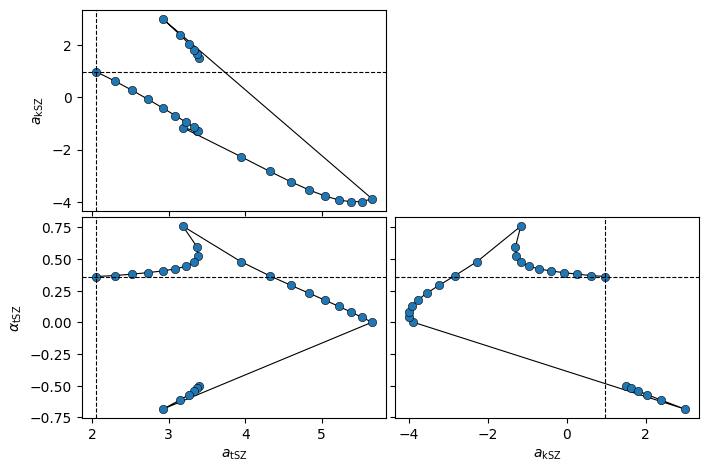

In [11]:
chain = np.array(trace)

params = ["a_tSZ", "a_kSZ", "alpha_tSZ"]
labels = [r"a_{\rm tSZ}", r"a_{\rm kSZ}", r"\alpha_{\rm tSZ}"]

fig, axes = plt.subplots(len(params), len(params), sharex="col", sharey="row", figsize = (12, 8), gridspec_kw={"hspace":0.03, "wspace":0.03})

for i, ipar in enumerate(params):
    for j, jpar in enumerate(params):
        ax = axes[i,j]
        if j >= i:
            fig.delaxes(ax)
            continue

        xpar = parameters_baseline.index(ipar)
        ypar = parameters_baseline.index(jpar)
        x = chain[:, xpar]
        y = chain[:, ypar]

        ax.plot(y, x, color="k", linewidth=0.8, marker="o", markerfacecolor="C0", markeredgewidth=0.4)
        ax.axvline(y[-1], c="k", ls="--", lw=0.8)
        ax.axhline(x[-1], c="k", ls="--", lw=0.8)

        if j == 0:
            ax.set_ylabel(f"${labels[i]}$")
        if i == len(params)-1:
            ax.set_xlabel(f"${labels[j]}$")

In [12]:
# Now, this worked somewhat, but straightforward minimizers are not always optimal for this method.
# Luckily, smarter people have implemented better methods. Here we explore the Adam minimizer from Optax.
import optax

# Annoyingly, these optimizers are all looking for minima, whereas our function has a maximum.
# Hence we need to redefine our logposterior to include a minus sign:
def logpost_adam(theta):
    # Add a minus sign
    return -logpost_baseline(theta)

grad_adam = jax.grad(logpost_adam)
hess_adam = jax.hessian(logpost_adam)

In [13]:
import random

# To make it more fun, we'll start at a random point near the best-fit.
random_point = {
    "a_tSZ": 4.5,
    "alpha_tSZ": 0.0,
    "a_kSZ": 1.0,
    "a_c": random.gauss(3.7, 0.5),
    "a_p": random.gauss(7.7, 1.0),
    "beta_cib": random.gauss(1.9, 0.2),
    "xi": random.uniform(0.01, 0.19),
    "a_s": random.gauss(2.9, 0.3),
    "beta_s": random.gauss(-2.8, 0.2),
    "a_pste": random.gauss(0.0, 0.01),
    "a_psee": random.uniform(0.01, 0.09),

    "a_gtt": random.gauss(7.95, 0.3),
    "a_gte": random.gauss(0.423, 0.03),
    "a_gee": random.gauss(0.1681, 0.03),

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

theta = jnp.array([ random_point[p] for p in parameters_baseline ])

In [14]:
optimizer = optax.adam(learning_rate=1e-1)
opt_state = optimizer.init(theta)

x_adam = theta.copy()
chain_adam = [x_adam]

for _ in tqdm(range(100)):
    updates, opt_state = optimizer.update(grad_adam(x_adam), opt_state, x_adam)
    x_adam = optax.apply_updates(x_adam, updates)
    chain_adam.append(x_adam)

chain_adam = np.array(chain_adam)

  0%|          | 0/100 [00:00<?, ?it/s]

a_tSZ 0.44740766
a_kSZ 1.2250973
alpha_tSZ 0.16868038


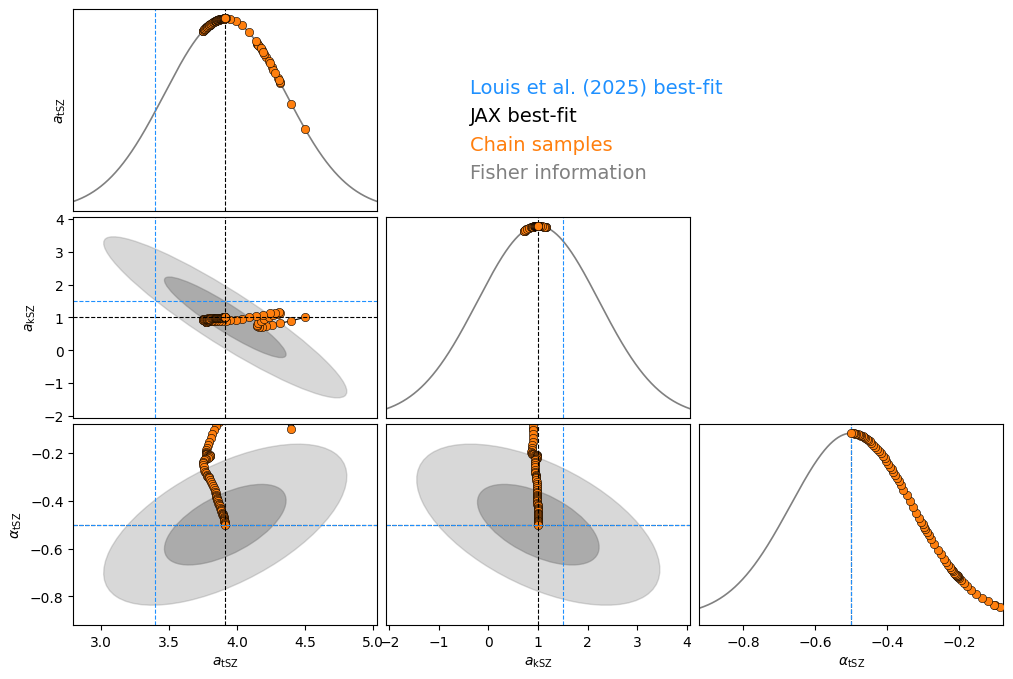

In [15]:
params = ["a_tSZ", "a_kSZ", "alpha_tSZ"]
labels = [r"a_{\rm tSZ}", r"a_{\rm kSZ}", r"\alpha_{\rm tSZ}"]

H = hess_adam(x_adam)
F = jnp.linalg.inv(H)
err = jnp.sqrt(jnp.diag(F))

# Here we plot the final chain.
# - in orange, we show the samples found using Optax.
# - in grey, we show the Fisher information matrix (which is a reasonable estimate of the posterior)
# - in blue, we show the Louis et al (2025) best-fitting parameters, and in black we show our own.

fig, axes = plt.subplots(len(params), len(params), figsize = (12, 8), gridspec_kw={"hspace":0.03, "wspace":0.03})

for i, ipar in enumerate(params):
    for j, jpar in enumerate(params):
        ax = axes[i,j]
        if j > i:
            fig.delaxes(ax)
            continue
        elif i == j:
            xpar = parameters_baseline.index(ipar)
            mean = chain_adam[-1, xpar]
            std = err[xpar]
            print(ipar, std)

            x = np.linspace(mean - 2.5 * std, mean + 2.5 * std, 1000)
            y = np.exp(-0.5 * np.power((x - mean) / std, 2.0))
            ax.plot(x, y, lw=1.2, c="grey")

            ax.axvline(mean, c="k", lw=0.8, ls="--")
            ax.axvline(parameter_values[ipar], c="dodgerblue", lw=0.8, ls="--")

            # Show the sample points along the slice
            y = np.exp(-0.5 * np.power((chain_adam[:,xpar] - mean) / std, 2.0))
            ax.scatter(chain_adam[:,xpar], y, marker="o", facecolor="C1", edgecolor="k", linewidth=0.4, zorder=99)
            
            ax.set_xlim(mean - 2.5 * std, mean + 2.5 * std)
            ax.set_yticks([])
        else:
            xpar = parameters_baseline.index(ipar)
            ypar = parameters_baseline.index(jpar)
            x = chain_adam[:, xpar]
            y = chain_adam[:, ypar]
    
            ax.plot(y, x, color="k", linewidth=0.8, marker="o", markerfacecolor="C1", markeredgewidth=0.4)
            ax.axvline(y[-1], c="k", lw=0.8, ls="--")
            ax.axhline(x[-1], c="k", lw=0.8, ls="--")
    
            ax.axvline(parameter_values[jpar], c="dodgerblue", lw=0.8, ls="--")
            ax.axhline(parameter_values[ipar], c="dodgerblue", lw=0.8, ls="--")
    
            add_ellipse(ax, [y[-1], x[-1]], [err[ypar], err[xpar]], F[xpar,ypar], nstd=1., color="grey", alpha=0.5)
            add_ellipse(ax, [y[-1], x[-1]], [err[ypar], err[xpar]], F[xpar,ypar], nstd=2., color="grey", alpha=0.3)
    
            ax.set_xlim(y[-1] - 2.5 * err[ypar], y[-1] + 2.5 * err[ypar])
            ax.set_ylim(x[-1] - 2.5 * err[xpar], x[-1] + 2.5 * err[xpar])

        if j == 0:
            ax.set_ylabel(f"${labels[i]}$")
        else:
            ax.set_yticks([])
        if i == len(params)-1:
            ax.set_xlabel(f"${labels[j]}$")
        else:
            ax.set_xticks([])

ax = axes[0,0]
ax.plot([], [], c="dodgerblue", label="Louis et al. (2025) best-fit")
ax.plot([], [], c="k", label="JAX best-fit")
ax.plot([], [], c="C1", label="Chain samples")
ax.plot([], [], c="grey", label="Fisher information")
L = ax.legend(loc=(1.1, 0.1), fontsize=14)
for t, h in zip(L.get_texts(), L.legend_handles):
	c = h.get_color()
	h.set_visible(False)
	t.set_color(c)
L.get_frame().set_edgecolor("none")